# **IPL MATCH ANALYSIS**

In [1]:
from google.colab import drive
import pandas as pd
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Mount the Drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/IPL_PROJECT/IPL_EDA_Base.csv'
df = pd.read_csv(file_path)


Mounted at /content/drive


# **1. TOSS IMPACT ANALYSIS**

Question: Does winnning the toss increase the chances of winning?

In [2]:
match_df = df.drop_duplicates(subset='match_id')
toss_analysis = match_df.copy()
toss_analysis['toss_win_match_win'] = (
    toss_analysis['toss_winner'] == toss_analysis['winner']
)

values=toss_analysis['toss_win_match_win'].value_counts(normalize=True) * 100
values

,proportion
toss_win_match_win,
True,50.556031
False,49.443969


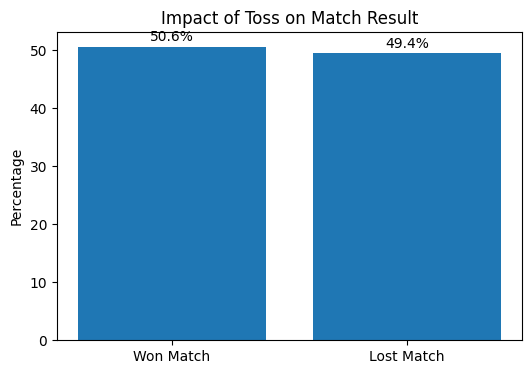

In [3]:

labels = [ 'Won Match','Lost Match']

plt.figure(figsize=(6,4))
plt.bar(labels,values)

plt.title('Impact of Toss on Match Result')
plt.ylabel('Percentage')

for i, v in enumerate(values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.show()

Insight: Winning the toss provides a slight advantage, but it is not a decisive factor in determining match outcomes

Winning the toss does not guarantee victory, indicating that match performance is more important than pre-match advantage

# **2. TOSS DECISION IMPACT ANALYSIS**

Question: Bat vs Field — which decision is better?

In [6]:

decision_win = match_df[match_df['toss_winner'] == match_df['winner']]

decision_analysis = decision_win.groupby('toss_decision').size().reset_index(name='count')

decision_analysis

,toss_decision,count
0,bat,183
1,field,408


In [5]:
decision_total = match_df.groupby('toss_decision').size()
decision_wins = match_df[match_df['toss_winner'] == match_df['winner']] \
    .groupby('toss_decision').size()

decision_pct = (decision_wins / decision_total) * 100
decision_pct = decision_pct.reset_index(name='win_percentage')
decision_pct

,toss_decision,win_percentage
0,bat,45.185185
1,field,53.403141


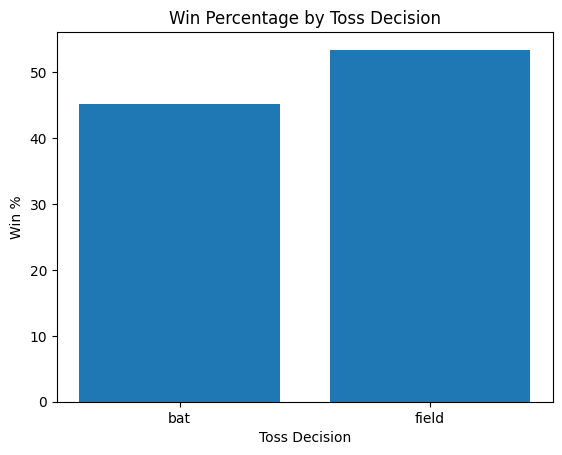

In [7]:
plt.bar(decision_pct['toss_decision'],decision_pct['win_percentage'] )

plt.title('Win Percentage by Toss Decision')
plt.ylabel('Win %')
plt.xlabel('Toss Decision')

plt.xticks(rotation=0)
plt.show()

Insight: Teams opting to field first show a slightly higher win percentage, suggesting that chasing provides a tactical advantage in T20 cricket.

# **3. Bat First vs Chasing**

Question: Is chasing easier than defending?

In [9]:
# Step 1: First innings only
match_df = df[df['innings'] == 1].drop_duplicates('match_id')

# Step 2: Batting first team
match_df['bat_first_team'] = match_df['batting_team']

# Step 3: Chasing team
match_df['chasing_team'] = match_df['bowling_team']

In [10]:
# winning %
bat_first_win_pct = (
    len(match_df[match_df['winner'] == match_df['bat_first_team']])
    / len(match_df)
) * 100

chase_win_pct = (
    len(match_df[match_df['winner'] == match_df['chasing_team']])
    / len(match_df)
) * 100
print("bat_first_win%"," : ",bat_first_win_pct)
print("bowling_first_win%"," : ", chase_win_pct )

bat_first_win%  :  44.91017964071856
bowling_first_win%  :  53.12232677502139


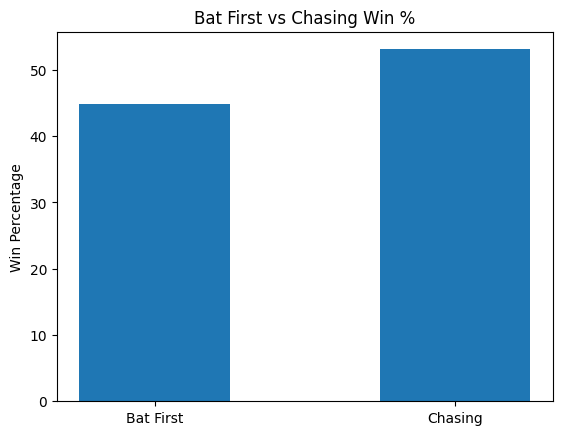

In [11]:

labels = ['Bat First', 'Chasing']
values = [bat_first_win_pct, chase_win_pct]

plt.bar(labels, values,width=0.5)

plt.ylabel('Win Percentage')
plt.title('Bat First vs Chasing Win %')

plt.show()

Insight: Teams batting second tend to win more matches, suggesting that the ability to assess the target and adapt the strategy accordingly provides a competitive advantage in T20 cricket

# **4. Venue Analysis**

Question: Which stadiums are batting-friendly or bowling-friendly?

In [ ]:
# Total runs per match
match_runs = df.groupby(['match_id', 'venue'])['runs_total'].sum().reset_index()
# Total runs per match
venue_avg = match_runs.groupby('venue')['runs_total'].mean().sort_values(ascending=False)
venue_counts = match_runs['venue'].value_counts()
# Filter meaningful venues
valid_venues = venue_counts[venue_counts > 30].index
venue_avg = venue_avg[venue_avg.index.isin(valid_venues)]
venue_avg

,runs_total
venue,
"Narendra Modi Stadium, Ahmedabad",345.311111
"Wankhede Stadium, Mumbai",330.568000
"Arun Jaitley Stadium, Delhi",327.824742
"M Chinnaswamy Stadium, Bengaluru",327.262626
"IS Bindra Stadium, Mohali",325.639344
"Eden Gardens, Kolkata",322.240000
"Sawai Mansingh Stadium, Jaipur",318.109375
"Rajiv Gandhi International Stadium, Hyderabad",317.975904
"MA Chidambaram Stadium, Chennai",314.340659


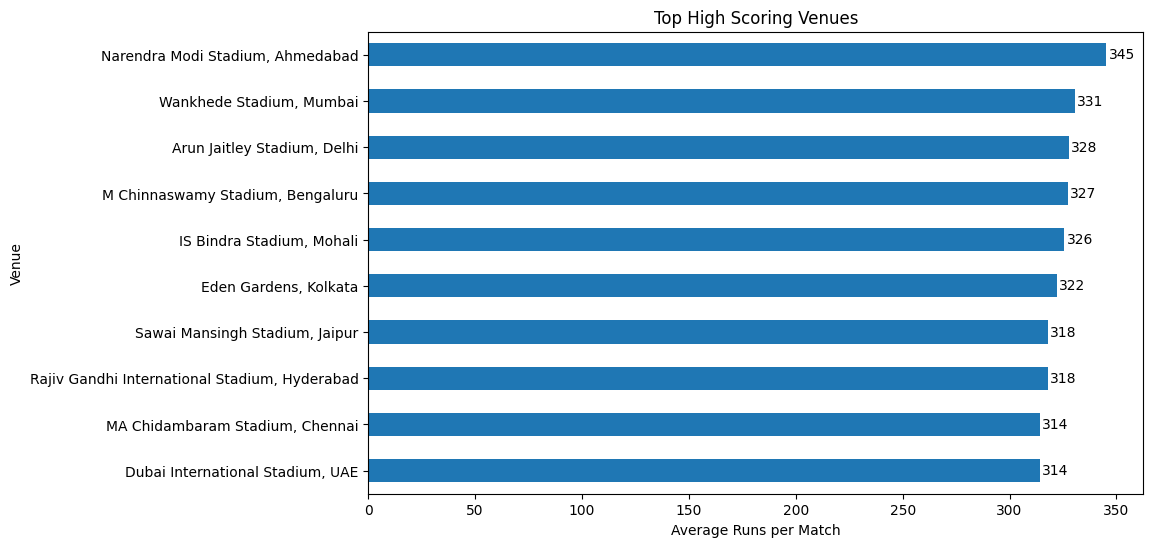

In [ ]:

ax = venue_avg.head(10).sort_values().plot(kind='barh', figsize=(10,6))

for i, v in enumerate(venue_avg.head(10).sort_values()):
    ax.text(v + 1, i, f"{v:.0f}", va='center')

plt.title('Top High Scoring Venues')
plt.xlabel('Average Runs per Match')
plt.ylabel('Venue')

plt.show()

Insight: Significant variation in average match scores across venues highlights the influence of pitch conditions and ground dimensions, with some venues clearly favoring batting while others support bowling dominance

# **5. Win Margin Analysis**

Question: Are matches close or one-sided?

In [ ]:
match_df['win_margin'].describe()

,win_margin
count,1146
unique,111
top,6 wickets
freq,127


In [12]:

match_df['win_margin_value'] = match_df['win_margin'].str.extract('(\d+)')

match_df = match_df.dropna(subset=['win_margin_value'])

match_df['win_margin_value'] = match_df['win_margin_value'].astype(int)
match_df['win_margin_type'] = match_df['win_margin'].str.extract('(runs|wickets)')
match_df

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_5591/3180183630.py:1: SyntaxWarning: invalid escape sequence '\d'
  match_df['win_margin_value'] = match_df['win_margin'].str.extract('(\d+)')


,match_id,season,date,innings,batting_team,bowling_team,over,ball,batter,bowler,...,is_four,is_six,is_boundary,is_dot,is_single,is_wicket,bat_first_team,chasing_team,win_margin_value,win_margin_type
0,335982,2008,2008-04-18,1,KKR,RCB,0,1,SC Ganguly,P Kumar,...,0,0,0,0,1,0,KKR,RCB,140,runs
225,335983,2008,2008-04-19,1,CSK,PBKS,0,1,PA Patel,B Lee,...,0,0,0,1,0,0,CSK,PBKS,33,runs
473,335984,2008,2008-04-19,1,RR,DC,0,1,T Kohli,GD McGrath,...,0,0,0,1,0,0,RR,DC,9,wickets
692,335985,2008,2008-04-20,1,MI,RCB,0,1,L Ronchi,P Kumar,...,0,0,0,1,0,0,MI,RCB,5,wickets
938,335986,2008,2008-04-20,1,SRH,KKR,0,1,AC Gilchrist,AB Dinda,...,0,0,0,0,1,0,SRH,KKR,5,wickets
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277070,1473507,2025,2025-05-27,1,LSG,RCB,0,1,MR Marsh,N Thushara,...,0,0,0,0,1,0,LSG,RCB,6,wickets
277314,1473508,2025,2025-05-29,1,PBKS,RCB,0,1,Priyansh Arya,B Kumar,...,0,0,0,0,0,0,PBKS,RCB,8,wickets
277461,1473509,2025,2025-05-30,1,MI,GT,0,1,RG Sharma,Mohammed Siraj,...,0,0,0,0,1,0,MI,GT,20,runs
277709,1473510,2025,2025-06-01,1,MI,PBKS,0,1,RG Sharma,Arshdeep Singh,...,0,0,0,1,0,0,MI,PBKS,5,wickets


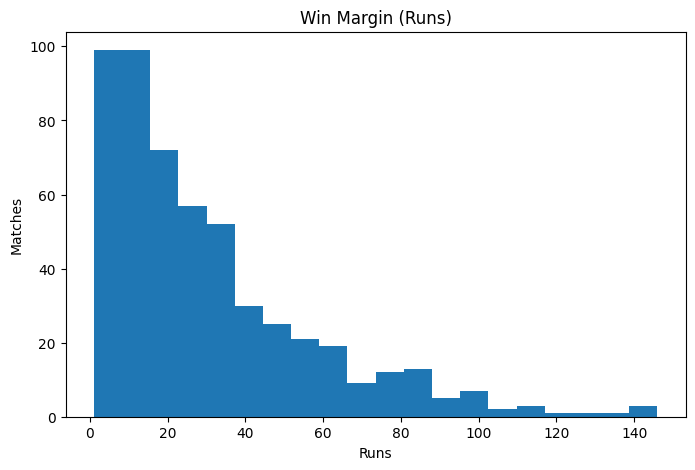

In [ ]:
runs_margin = match_df[match_df['win_margin_type'] == 'runs']

plt.figure(figsize=(8,5))
plt.hist(runs_margin['win_margin_value'], bins=20)

plt.title('Win Margin (Runs)')
plt.xlabel('Runs')
plt.ylabel('Matches')
plt.show()

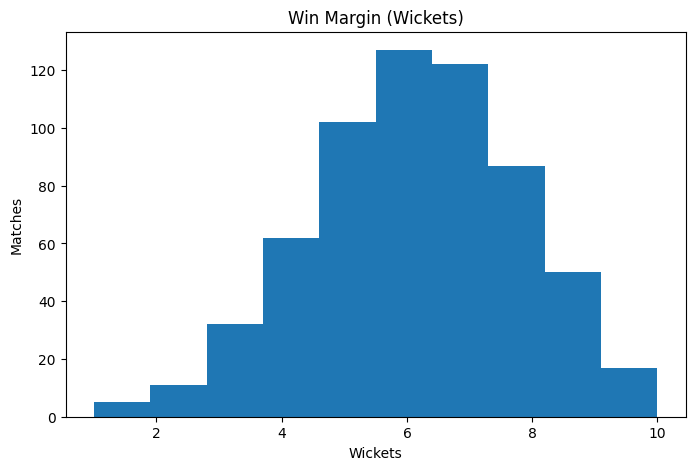

In [ ]:
wickets_margin = match_df[match_df['win_margin_type'] == 'wickets']

plt.figure(figsize=(8,5))
plt.hist(wickets_margin['win_margin_value'], bins=10)

plt.title('Win Margin (Wickets)')
plt.xlabel('Wickets')
plt.ylabel('Matches')

plt.show()

Insight: Run-margin victories tend to vary widely, indicating dominant performances in some matches, whereas wicket-margin wins are more clustered, reflecting the structured nature of successful chases.

The distribution of win margins indicates that while some matches are one-sided, a substantial number are closely contested, reflecting the competitive nature of the IPL.

# **Player Of The Match Impact**

Question: Do top players influence wins heavily?

In [ ]:
# Get unique matches (so we don't count the same POTM for every ball)
unique_matches = df.drop_duplicates('match_id')

# 2. Get the Top 10
top_10_players = unique_matches['player_of_match'].value_counts().head(10)

print("🏆 THE ALL-TIME POTM LEADERBOARD (2008-2025)")
print("-" * 45)
print(top_10_players)

🏆 THE ALL-TIME POTM LEADERBOARD (2008-2025)
---------------------------------------------
player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         21
V Kohli           19
DA Warner         18
MS Dhoni          18
SP Narine         17
AD Russell        16
SR Watson         16
YK Pathan         16
Name: count, dtype: int64


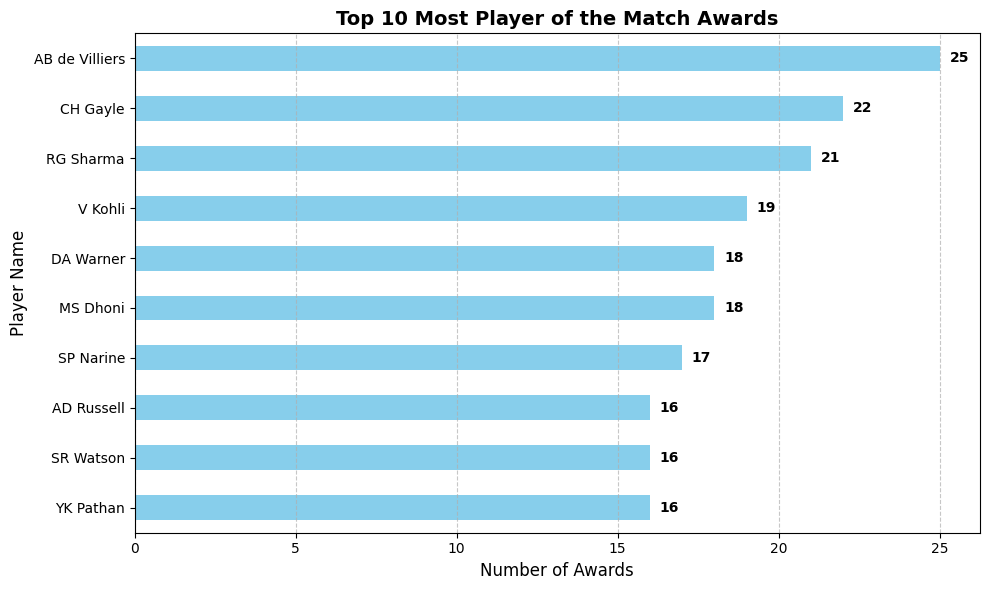

In [ ]:
plt.figure(figsize=(10, 6))

# 1. Create the horizontal bar plot
ax = top_10_players.plot(kind='barh', color='skyblue')
ax.invert_yaxis()

# 2. Add titles and labels
plt.title('Top 10 Most Player of the Match Awards', fontsize=14, fontweight='bold')
plt.xlabel('Number of Awards', fontsize=12)
plt.ylabel('Player Name', fontsize=12)

# 3. Add the count labels at the end of each bar
for i, v in enumerate(top_10_players):
    ax.text(v + 0.3, i, str(v), color='black', va='center', fontweight='bold')

# 4. Clean up the display
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Insight: Certain players consistently win Player of the Match awards, indicating their strong influence on match outcomes

# **Final Match analysis summary**




Match outcomes in IPL are influenced by a combination of strategic decisions, player performances, and venue conditions. While chasing provides a slight advantage, toss results alone are not decisive. The variation in venue characteristics and the presence of both close and dominant victories highlight the dynamic and competitive nature of the tournament

In [13]:
path = '/content/drive/My Drive/IPL_PROJECT/'
match_df.to_csv(path + 'IPL_match_level.csv', index=False)